In [2]:
import pandas as pd

from utils import get_importance_score, display_distributions

In [3]:
data = pd.read_csv("./data/train.csv", index_col=0)

to_lag = ["forward_returns", "risk_free_rate", "market_forward_excess_returns"]
to_drop = ["E7", "V10", "S3", "M1", "M13", "M14", "M6", "V9"]  #缺失值多，直接删除列

#处理bool列
for i in range(1, 10):
    data[f"D{i}"] = data[f"D{i}"] != 0
    data[f"D{i}"] = data[f"D{i}"].astype("category")

#处理收益率列
for i in to_lag:
    data[f"lag_{i}"] = data[i].shift(1)

data["target"] = (data["forward_returns"] - data["risk_free_rate"]) > 0  #使用指数收益率是否大于无风险利率作为预测值
data = data.drop(to_drop + to_lag, axis=1)
data = data[-5400:]
data

,D1,D2,D3,D4,D5,D6,D7,D8,D9,E1,...,V3,V4,V5,V6,V7,V8,lag_forward_returns,lag_risk_free_rate,lag_market_forward_excess_returns,target
date_id,,,,,,,,,,,,,,,,,,,,,
3621,False,False,False,True,False,False,False,False,False,1.069307,...,0.114418,0.252646,-0.070909,0.000661,-1.007954,0.000661,0.008454,0.000041,0.008105,True
3622,False,False,True,True,False,False,False,False,False,1.068143,...,0.248677,0.326720,-0.221641,0.000661,-1.081144,0.000661,0.006378,0.000041,0.006029,False
3623,False,False,False,True,False,False,False,False,False,1.066981,...,0.093915,0.316138,-0.011475,0.000661,-0.956609,0.000661,-0.004165,0.000040,-0.004513,True
3624,False,False,False,True,False,False,False,False,False,1.065821,...,0.119048,0.341270,-0.172679,0.000661,-1.023332,0.000661,0.000455,0.000039,0.000108,False
3625,False,False,False,False,False,False,False,False,False,1.064664,...,0.111111,0.326058,-0.171993,0.000661,-0.766254,0.000661,-0.008542,0.000038,-0.008889,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9016,False,False,False,True,False,False,False,False,False,1.493117,...,0.208995,0.484788,0.717308,0.677249,-0.327455,0.083995,0.010401,0.000152,0.009936,False
9017,False,False,False,True,False,False,False,False,False,1.490889,...,0.082011,0.482804,1.001028,0.596561,-0.372979,0.094246,-0.000015,0.000151,-0.000477,False
9018,False,False,False,True,False,True,False,False,False,1.488667,...,0.334656,0.486772,0.894502,0.656746,-0.282024,0.090608,-0.005199,0.000150,-0.005661,True


In [4]:
x = data.drop("target", axis=1)
y = data["target"]
score_df, importance_df, null_importance_df = get_importance_score(x, y)
score_df  # rank越高的特征越重要

计算Importance
计算Null Importance


100%|██████████| 80/80 [00:32<00:00,  2.50it/s]


,feature,split_score,gain_score,split_rank,gain_rank,rank
43,M18,0.647006,0.828680,89.0,89.0,89.0
20,E2,0.500401,0.587724,88.0,87.0,87.5
59,P5,0.308091,0.588580,85.0,88.0,86.5
19,E19,0.364518,0.445443,86.0,85.0,85.5
68,S2,0.372902,0.325935,87.0,83.0,85.0
...,...,...,...,...,...,...
8,D9,-2.833213,-3.624097,5.0,5.0,5.0
0,D1,-23.025851,-23.025851,2.5,2.5,2.5
2,D3,-23.025851,-23.025851,2.5,2.5,2.5
1,D2,-23.025851,-23.025851,2.5,2.5,2.5


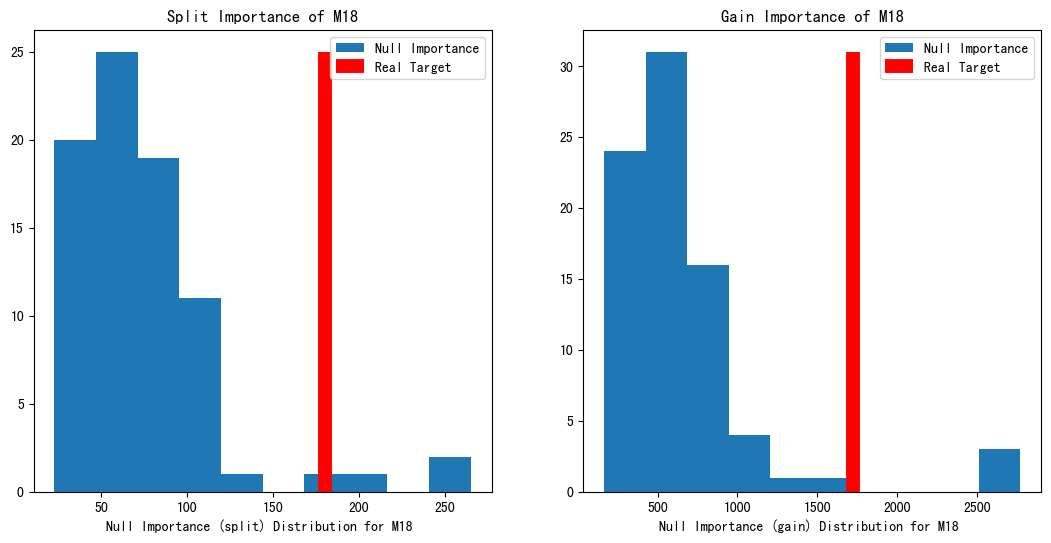

In [5]:
display_distributions(importance_df, null_importance_df, "M18")